
Seahawks vs 49ers — Player Props Tracking (Full Version)

╒═════════════╤═════════════════╤═════════════════╤════════════════╤══════════════╤══════════════════════════╤══════════════╤════════════════════════════╤══════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════╤═══════════╕
│ Player      │ Prop            │   Baseline Prop │   Current Prop │   Baseline % │ Date Logged (Baseline)   │   Adjusted % │ Date Logged (Adjustment)   │ Risk Tier                │ Rationale                                                                                               │   Line Movement │   Delta % │
╞═════════════╪═════════════════╪═════════════════╪════════════════╪══════════════╪══════════════════════════╪══════════════╪════════════════════════════╪══════════════════════════╪═════════════════════════════════════════════════════════════════════════════════════════════════════════╪═════════════════╪

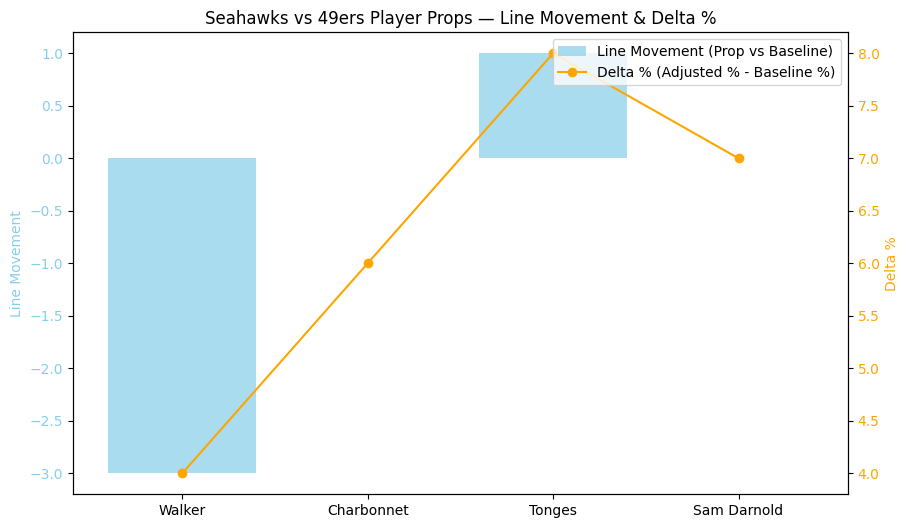

In [6]:
# ================================
# Seahawks vs 49ers Player Props 
# ================================

# Step 1: Imports
import pandas as pd
from datetime import datetime
from tabulate import tabulate
import matplotlib.pyplot as plt

# Step 2: Player Props Table
data = [
    {
        "Player": "Walker",
        "Prop": "Rushing Yards",
        "Baseline Prop": 58.5,
        "Current Prop": 55.5,
        "Baseline %": 62,
        "Date Logged (Baseline)": "2026-01-16 09:30",
        "Adjusted %": 66,
        "Date Logged (Adjustment)": "2026-01-17 15:45",
        "Risk Tier": "Core (Market-Challenged)",
        "Rationale": "Interior run defense vulnerability, Walker burst favors inside lanes while Charbonnet used more outside"
    },
    {
        "Player": "Charbonnet",
        "Prop": "Receptions",
        "Baseline Prop": 2.0,
        "Current Prop": 2.0,
        "Baseline %": 58,
        "Date Logged (Baseline)": "2026-01-16 09:35",
        "Adjusted %": 64,
        "Date Logged (Adjustment)": "2026-01-17 15:45",
        "Risk Tier": "Core (Market-Neutral)",
        "Rationale": "49ers struggle covering RBs in flat, short-area usage increases under pressure"
    },
    {
        "Player": "Tonges",
        "Prop": "Receiving Yards",
        "Baseline Prop": 34.5,
        "Current Prop": 35.5,
        "Baseline %": 55,
        "Date Logged (Baseline)": "2026-01-16 09:40",
        "Adjusted %": 63,
        "Date Logged (Adjustment)": "2026-01-17 15:45",
        "Risk Tier": "Core (Market-Confirmed)",
        "Rationale": "Purdy safety valve vs pressure, Seahawks pass rush forces checkdowns/Shell coverage"
    },
    {
        "Player": "Sam Darnold",
        "Prop": "Interceptions",
        "Baseline Prop": 0.5,
        "Current Prop": 0.5,
        "Baseline %": 61,
        "Date Logged (Baseline)": "2026-01-16 09:45",
        "Adjusted %": 68,
        "Date Logged (Adjustment)": "2026-01-17 15:45",
        "Risk Tier": "High-Variance Conviction",
        "Rationale": "Pressure-induced decision errors, turnover history in high-leverage games"
    }
]

# Step 3: Create DataFrame
df = pd.DataFrame(data)

# Step 4: Derived Metrics
df["Line Movement"] = df["Current Prop"] - df["Baseline Prop"]
df["Delta %"] = df["Adjusted %"] - df["Baseline %"]

# Step 5: Display Table
print("\nSeahawks vs 49ers — Player Props Tracking (Full Version)\n")
print(tabulate(df, headers="keys", tablefmt="fancy_grid", showindex=False))

# Step 6: Save Snapshot
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
filename = f"Seahawks_49ers_Props_Full_{timestamp}.csv"
df.to_csv(filename, index=False)
print(f"\nSnapshot saved as: {filename}")

# Step 7: Quick Summary
print("\n--- Quick Summary ---\n")
for i, row in df.iterrows():
    print(f"{row['Player']} ({row['Prop']}) | Risk: {row['Risk Tier']} | Line Move: {row['Line Movement']:+} | Δ%: {row['Delta %']:+}")

# Step 8: Visual Analysis
fig, ax1 = plt.subplots(figsize=(10,6))

players = df["Player"]
line_move = df["Line Movement"]
delta_pct = df["Delta %"]

# Bar for line movement
ax1.bar(players, line_move, color='skyblue', alpha=0.7, label='Line Movement (Prop vs Baseline)')
ax1.set_ylabel('Line Movement', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_title('Seahawks vs 49ers Player Props — Line Movement & Delta %')

# Line for Delta %
ax2 = ax1.twinx()
ax2.plot(players, delta_pct, color='orange', marker='o', label='Delta % (Adjusted % - Baseline %)')
ax2.set_ylabel('Delta %', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Legend
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

plt.show()

# Step X: Define Final Lean (Pre-Game Decision)
lean_map = {
    "Walker": "OVER",
    "Charbonnet": "OVER",
    "Tonges": "OVER",
    "Sam Darnold": "OVER"
}

df["Lean"] = df["Player"].map(lean_map)



In [ ]:
# ================================
# Derived Metrics
# ================================

# Create Lean column from Adjusted %
df["Lean"] = df["Adjusted %"].apply(lambda x: "OVER" if x > 50 else "UNDER")

# Calculate Line Movement
df["Line Movement"] = df["Current Prop"] - df["Baseline Prop"]

# Calculate Delta % (Adjusted % - Baseline %)
df["Delta %"] = df["Adjusted %"] - df["Baseline %"]


In [4]:
# ================================
# Post-Game Outcome Tracking & Accuracy
# ================================

# Ensure Lean column exists
if 'Lean' not in df.columns:
    df['Lean'] = df['Adjusted %'].apply(lambda x: "OVER" if x > 50 else "UNDER")

# Handle Injuries / VOID
df.loc[df['Player'] == "Charbonnet", "Outcome"] = "NO ACTION"

# Enter actual outcomes from the game
post_game_outcomes = {
    "Walker": "OVER",      # HIT
    "Tonges": "OVER",      # HIT
    "Sam Darnold": "UNDER" # MISS (High-Variance)
}

# Update DataFrame with outcomes
for player, outcome in post_game_outcomes.items():
    df.loc[df['Player'] == player, 'Outcome'] = outcome

# Check accuracy per prop (True/False, None for NO ACTION)
df['Hit'] = df.apply(
    lambda row: None if row['Outcome'] == 'NO ACTION' else row['Lean'] == row['Outcome'],
    axis=1
)

# Overall hit %
overall_hit = df['Hit'].dropna().mean() * 100

# Hit % by Risk Tier
risk_summary = df.dropna(subset=['Hit']).groupby('Risk Tier')['Hit'].mean() * 100

# Display results
print("\n--- Post-Game Accuracy ---\n")
print(f"Overall Hit %: {overall_hit:.1f}%\n")
print("Hit % by Risk Tier:")
print(risk_summary.to_string())

# Updated table with outcomes
print("\nUpdated Table with Outcomes:\n")
from tabulate import tabulate
print(tabulate(df, headers='keys', tablefmt='fancy_grid', showindex=False))



--- Post-Game Accuracy ---

Overall Hit %: 66.7%

Hit % by Risk Tier:
Risk Tier
Core (Market-Challenged)    100.0
Core (Market-Confirmed)     100.0
High-Variance Conviction      0.0

Updated Table with Outcomes:

╒═════════════╤═════════════════╤═════════════════╤════════════════╤══════════════╤══════════════════════════╤══════════════╤════════════════════════════╤══════════════════════════╤═════════════════════════════════════════════════════════════════════════════════════════════════════════╤═════════════════╤═══════════╤════════╤═══════════╤═══════╕
│ Player      │ Prop            │   Baseline Prop │   Current Prop │   Baseline % │ Date Logged (Baseline)   │   Adjusted % │ Date Logged (Adjustment)   │ Risk Tier                │ Rationale                                                                                               │   Line Movement │   Delta % │ Lean   │ Outcome   │ Hit   │
╞═════════════╪═════════════════╪═════════════════╪════════════════╪══════════════╪═════════

In [ ]:
# Only count valid outcomes (exclude NO ACTION / PUSH / INJURY)
valid_results = df.loc[df['Outcome'].isin(["OVER", "UNDER"])].copy()
valid_results["Hit"] = valid_results["Lean"] == valid_results["Outcome"]
overall_hit = valid_results["Hit"].mean() * 100
print(f"\nOverall Hit %: {overall_hit:.1f}%")

In [10]:
postgame_filename = f"Seahawks_49ers_PostGame_{timestamp}.csv"
df.to_csv(postgame_filename, index=False)
print(f"Post-game snapshot saved as: {postgame_filename}")


Post-game snapshot saved as: Seahawks_49ers_PostGame_20260117_1601.csv


## Post-Game Reflection — Seahawks vs 49ers

### Results Summary
- Core Props: 2 / 2
- High-Variance Props: 0 / 1
- Injury / No Action: 1 (Excluded)

### Key Takeaways
- Market-challenged and market-confirmed core reads both hit.
- High-variance interception prop missed as expected within risk labeling.
- Injury outcomes were properly excluded from performance metrics.

### Evaluation
This slate reinforces the importance of separating core decisions from high-variance conviction plays and excluding uncontrollable events (injuries) from accuracy evaluation.

### Next Iteration Improvements
- Track multiple slates to measure long-term performance.
- Compare hit rate across Market-Challenged vs Market-Confirmed props.
- Expand risk classification granularity.
